<div style="padding:20px;color:white;font-size:240%;text-align:center;border-radius:5px;background-color:#023c66;font-weight:700;border:5px solid #F28C28;">Module 3 — Worksheet 2: SVD and Principal Component Analysis</div>

**Course:** ISA 591 — Introduction to Data Mining in Business  
**Module 3:** Dimension Reduction  
**Focus:** Variance, covariance, SVD, PCA, scaling, explained variance, loadings, and visualization

## Learning Goals

1. Explain variance and covariance as measures of variation.
2. Describe SVD conceptually as a matrix decomposition.
3. Explain how PCA creates uncorrelated linear combinations.
4. Calculate and interpret a simple principal-component score.
5. Explain why standardization matters before PCA.
6. Fit PCA and interpret explained variance.
7. Use cumulative variance and scree plots to choose components.
8. Interpret PCA loadings.
9. Visualize observations in principal-component space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",100)
print("Ready!")

Ready!


## Big Picture

PCA is useful when:

- there are many **numeric predictors**
- predictors measure related behaviors and may be correlated
- we want fewer dimensions while preserving most of the variation
- retaining the original variable names is less important than retaining information

### Business setting

An e-commerce website records many measures of customer behavior during each visit. Several measures describe related aspects of browsing, engagement, and abandonment.

> **Business question:** Can we summarize 10 overlapping web-behavior measures with a smaller number of underlying behavioral dimensions?

PCA is **unsupervised**: we will create the components from the behavioral variables only. `Revenue` will be used later only to help visualize whether purchasing sessions look different in PCA space.

---
# 1. Online Shoppers Purchasing Intention Data

Each row represents a website session. The dataset contains behavioral measures, contextual information, and a `Revenue` indicator showing whether the session ended in a purchase.

In [2]:
url = "https://raw.githubusercontent.com/martinwg/ISA591/refs/heads/main/data/online_shoppers_intention.csv"

shopping = pd.read_csv(url)

print("Shape:", shopping.shape)
shopping.head()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
## .info()
shopping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

<Axes: >

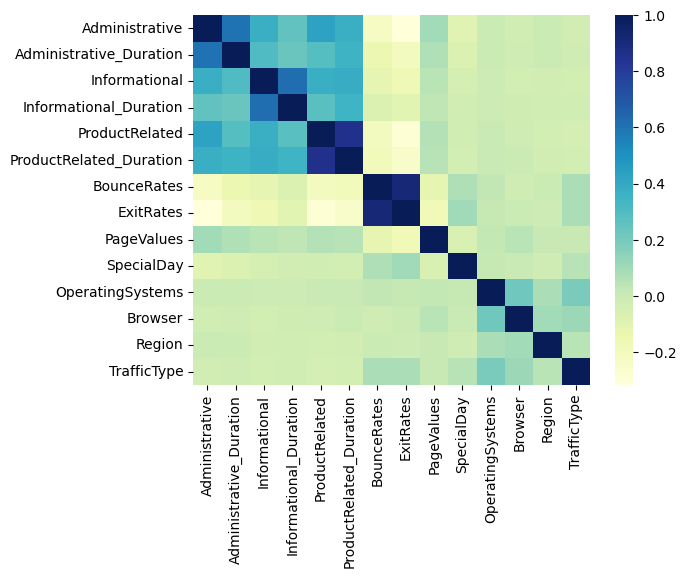

In [7]:
## correlation heatmap for numeric variables
corrmat = shopping.select_dtypes('number').corr()

## sns heatmap can show better the correlations
import seaborn as sns

sns.heatmap(corrmat, cmap = "YlGnBu")

## Variable Description

### Behavioral variables used for PCA

| Variable | Description |
|---|---|
| `Administrative` | Number of administrative pages visited |
| `Administrative_Duration` | Time spent on administrative pages |
| `Informational` | Number of informational pages visited |
| `Informational_Duration` | Time spent on informational pages |
| `ProductRelated` | Number of product-related pages visited |
| `ProductRelated_Duration` | Time spent on product-related pages |
| `BounceRates` | Average bounce rate of pages visited during the session |
| `ExitRates` | Average exit rate of pages visited during the session |
| `PageValues` | Average page value for pages visited before an e-commerce transaction |
| `SpecialDay` | Closeness of the visit to a special shopping day |

### Other variables

| Variable | Description |
|---|---|
| `Month` | Month of the session |
| `OperatingSystems` | Operating-system category |
| `Browser` | Browser category |
| `Region` | Geographic region category |
| `TrafficType` | Traffic-source category |
| `VisitorType` | Visitor category (for example, returning or new visitor) |
| `Weekend` | Whether the session occurred on a weekend |
| `Revenue` | Whether the session ended in a purchase |

> **Important:** `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are stored as integers, but they are categorical codes. Numeric storage does not make them continuous measurements, so we will not include them in this PCA.

## Practice 1A — Create the behavioral predictor matrix

Select the 10 continuous/count behavioral measures that will be summarized using PCA.

In [8]:
behavior_vars = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

X = shopping[behavior_vars].copy()

print("X shape:", X.shape)
X.head()

X shape: (12330, 10)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0


---
# 2. Variation, Covariance, and Redundancy

PCA uses **variance** and **covariance**.

### Variance
Measures how much one variable varies across customer sessions.

### Covariance
Measures how two variables vary together.

If two behavioral measures move together strongly, they may contain overlapping information.

We will begin with `BounceRates` and `ExitRates`, two conceptually related measures of website abandonment.

In [ ]:
## variance of BounceRates
X['BounceRates'].var()   ## [BounceRate - mean(BounceRates)]^2 / (N -1)

0.002351117351587493

In [11]:
## variance of ProductRelated_Duration
X['ProductRelated_Duration'].var()

3662130.143344541

In [ ]:
## which variable do you think brings the most INFORMATION?
#### We need to standardize first 

#### standardization could be dividing by the std dev
std_bouncerates = (X['BounceRates'] - X['BounceRates'].mean()) / X['BounceRates'].std()

1.0000000000000007

In [16]:
## COVARIANCE: measures how two variables vary together (.cov() -- returns both the var and cov)

np.round( X[['BounceRates','ProductRelated_Duration']].cov(), 3 )


,BounceRates,ProductRelated_Duration
BounceRates,0.002,-17.124
ProductRelated_Duration,-17.124,3662130.143


In [ ]:
## covariance can be negative: the vary negatively together (when 1 increases the other decreases)
## covariance can be positive: positive correlation
## cov(bounce rates and product related duration) = -17.124
## covariance is zero if there is no relationship (linear)

In [ ]:
## Correlation is actually computed from the covariance
## corr(x,y) = cov(x,y) / std(x)*std(y)

In [19]:
X[['BounceRates','ProductRelated_Duration', "ExitRates"]].cov()

## get the cov matrix
##1) what is the var of exit rates
##### 0.002362

##2) the cov between exit rates and bounce rates
##### 0.002151 (positive)

## 3) is there a 3-way cov
##### no, cov can only be computed for pairs

,BounceRates,ProductRelated_Duration,ExitRates
BounceRates,0.002351,-1.712368e+01,0.002151
ProductRelated_Duration,-17.123683,3.662130e+06,-23.433943
ExitRates,0.002151,-2.343394e+01,0.002362


In [20]:
X[['BounceRates','ProductRelated_Duration', "ExitRates"]].corr()

,BounceRates,ProductRelated_Duration,ExitRates
BounceRates,1.000000,-0.184541,0.913004
ProductRelated_Duration,-0.184541,1.000000,-0.251984
ExitRates,0.913004,-0.251984,1.000000


## Practice 2A — Examine two related behavioral variables

In [21]:
two = X[["BounceRates", "ExitRates"]]

print("Variances:")
print(two.var())

print("\nCovariance matrix:")
print(two.cov())

print("\nCorrelation matrix:")
print(two.corr())

Variances:
BounceRates    0.002351
ExitRates      0.002362
dtype: float64

Covariance matrix:
             BounceRates  ExitRates
BounceRates     0.002351   0.002151
ExitRates       0.002151   0.002362

Correlation matrix:
             BounceRates  ExitRates
BounceRates     1.000000   0.913004
ExitRates       0.913004   1.000000


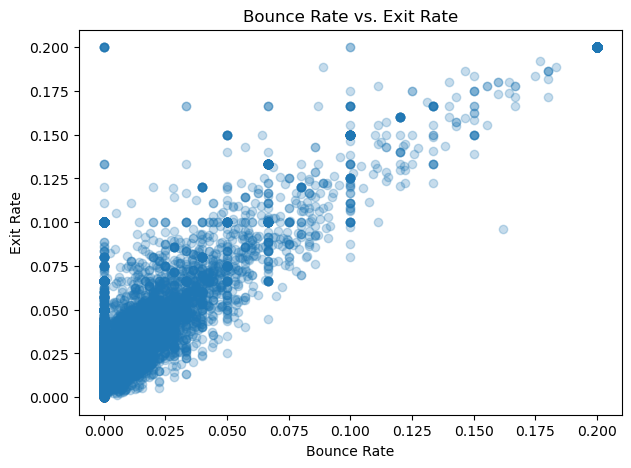

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(two["BounceRates"], two["ExitRates"], alpha=0.25)
plt.xlabel("Bounce Rate")
plt.ylabel("Exit Rate")
plt.title("Bounce Rate vs. Exit Rate")
plt.show()

### Question

What does the relationship suggest about redundancy between these two behavioral measures?

**Your response:**  
-

---
# 3. Covariance Matrix

For two variables, the covariance matrix has the form:

$$
\begin{bmatrix}
Var(X_1) & Cov(X_1,X_2) \\
Cov(X_1,X_2) & Var(X_2)
\end{bmatrix}
$$

The diagonal contains **variances**.  
The off-diagonal contains **covariances**.

## Practice 3A — Identify the entries

In [23]:
cov_matrix=two.cov()
cov_matrix

,BounceRates,ExitRates
BounceRates,0.002351,0.002151
ExitRates,0.002151,0.002362


Answer:

1. Where is $Var(BounceRates)$?
2. Where is $Var(ExitRates)$?
3. Why does covariance appear twice?

**Your response:**  
1.  
2.  
3.

---
# 4. Singular Value Decomposition (SVD)

SVD factorizes a matrix:

$$
X=U\Sigma V^T
$$

Conceptually:

- $U$ → new directions/representation of observations
- $\Sigma$ → importance or strength of each direction
- $V^T$ → weights describing how original variables contribute

SVD is widely used in dimension reduction, recommendation systems, text analysis, and compression.

In [ ]:
## we can use np.linalg.svd ----- returns ------U S V
## U contains columns (combinations of the original matrix X) but ordered according to how much information they bring
#### Columns of U are completely uncorrelated

## S contains the singular values (weights) telling you how important each column of U is


## example
#### 12000 x 1000  ---   U (12000 x 1000)    S (1000 x 1000)     V
#### we could keep the top columns of U say (12000 x 50)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0


## Practice 4A — Compute an SVD

In [ ]:
X_small = two.to_numpy()
X_centered = X_small - X_small.mean(axis=0)

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print("X shape:", X_centered.shape)
print("U shape:", U.shape)
print("S:", S)
print("Vt shape:", Vt.shape)

X shape: (12330, 2)
U shape: (12330, 2)
S: [7.45493318 1.58976614]
Vt shape: (2, 2)


## Practice 4B — Reconstruct the matrix

In [ ]:
# TODO
X_reconstructed = None

# Hint:
# X_reconstructed = U @ np.diag(S) @ Vt

print("Original centered first row:", X_centered[0])
print("Reconstructed first row:",
      None if X_reconstructed is None else X_reconstructed[0])

Original centered first row: [0.17780862 0.1569272 ]
Reconstructed first row: None


### Interpretation

Why is matrix decomposition useful for dimension reduction?

**Your response:**  
-

### Illustration of SVD Decomposition

In [28]:
# !pip install scikit-image

import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io

# Load an image from a URL or a file path
image = io.imread('data\cat1.jpg')

# Convert the image to grayscale
gray_image = color.rgb2gray(image)
gray_image.shape

(1282, 960)

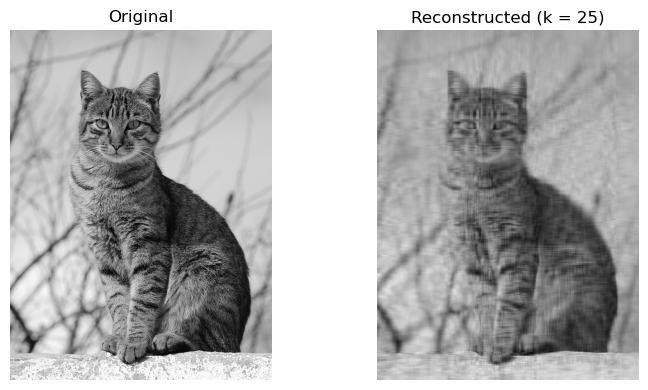

In [33]:
## This code illustrates the use of Singular Value Decomposition
## We compress an image using the singular values

import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io

# Load an image from a URL or a file path
image = io.imread('data\cat1.jpg')

# Convert the image to grayscale
gray_image = color.rgb2gray(image)

# Perform Singular Value Decomposition
U, S, V = np.linalg.svd(gray_image, full_matrices=False)

# Reconstruct the image using only the first k singular values
def reconstruct_image(U, S, V, k):
    S_k = np.diag(S[:k])  # Keep only the first k singular values
    U_k = U[:, :k]        # First k columns of U
    V_k = V[:k, :]        # First k rows of V
    return np.dot(U_k, np.dot(S_k, V_k))

# Number of singular values to use for the reconstruction
k = 25  # You can change this value to see how it affects the reconstruction

# Reconstruct the image using k singular values
reconstructed_image = reconstruct_image(U, S, V, k)

# Plot the original and reconstructed image
plt.figure(figsize=(8, 4))

# Original grayscale image
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original')
plt.axis('off')

# Reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f'Reconstructed (k = {k})')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 5. Principal Component Analysis

PCA creates new variables called **principal components**.

Each PC is a linear combination of the original variables:

$$
PC_1=a_{11}X_1+a_{12}X_2+\cdots+a_{1p}X_p
$$

Important properties:

1. PC1 captures the largest possible variance.
2. PC2 captures the largest remaining variance.
3. PCs are uncorrelated with one another.
4. With $p$ original variables, there can be up to $p$ PCs.
5. Keeping all PCs preserves the information; reduction occurs when we keep only the leading PCs.

## Practice 5A — Fit PCA to two variables

In [ ]:
from sklearn.decomposition import PCA

pca2=PCA(n_components=2)

# TODO
PCs_2=None
# PCs_2 = pca2.fit_transform(X)

# print("Explained variance ratio:",pca2.explained_variance_ratio_)

### Question

Which component contains more variation? How can you tell?

**Your response:**  
-

---
# 6. Calculating a PC Score

Scikit-learn centers each variable before PCA.

For two variables:

$$
PC_1=a_1(X_1-\bar X_1)+a_2(X_2-\bar X_2)
$$

The coefficients $a_1$ and $a_2$ are the **loadings/weights**.

In [ ]:
# Run after completing the PCA above
# print("PC loadings:")
# print(pca2.components_)

# print("\nMeans:")
# print(pca2.mean_)

## Practice 6A — Calculate the first observation's PC1 manually

In [ ]:
# TODO after pca2 has been fit
# row0 = two.iloc[0].to_numpy()
# centered = row0 - pca2.mean_
# manual_pc1 = centered @ pca2.components_[0]

manual_pc1=None

print("Manual PC1:",manual_pc1)

# Compare with:
# print("PCA PC1:",PCs_2[0,0])

### Key idea

A PC is **not one original variable**. It is a weighted combination of all variables included in the PCA.

---
# 7. Why Standardize Before PCA?

Now we move from two variables to all 10 behavioral variables.

They are measured on very different scales:

- page counts
- durations
- rates
- page values
- proximity to a special day

PCA searches for variance. Variables measured on larger numerical scales can dominate the components simply because of their units.

Standardization puts the variables on comparable scales:

$$
z=\frac{x-\bar{x}}{s}
$$

## Practice 7A — Compare scales

In [ ]:
X.describe().loc[["mean","std","min","max"]]

## Practice 7B — Standardize

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

# TODO
X_scaled=None
# X_scaled = scaler.fit_transform(X)

# print("Scaled means:",np.round(X_scaled.mean(axis=0),3))
# print("Scaled SDs:",np.round(X_scaled.std(axis=0),3))

### Question

Which online-shopping variables have much larger numerical scales than others? What could happen if PCA were performed without standardizing?

**Your response:**  
-

---
# 8. PCA on All Behavioral Variables

Now fit PCA using the standardized 10-variable customer-behavior matrix.

In [ ]:
pca=PCA()

# TODO
PCs=None
# PCs = pca.fit_transform(X_scaled)

# print("PC matrix shape:",PCs.shape)
# print("Number of components:",pca.n_components_)

## Practice 8A — Create a PC DataFrame

In [ ]:
# TODO
PC_df=None

# Hint:
# PC_df=pd.DataFrame(
#     PCs,
#     columns=[f"PC{i+1}" for i in range(PCs.shape[1])],
#     index=X.index
# )

# PC_df.head()

## Practice 8B — Verify that PCs are uncorrelated

In [ ]:
# TODO
# pc_corr=PC_df.corr()
# np.round(pc_corr.iloc[:5,:5],3)

---
# 9. Explained Variance

`explained_variance_ratio_` tells us the proportion of total standardized variance captured by each component.

The cumulative explained variance answers:

> **How much information have we retained if we keep the first $k$ PCs?**

In [ ]:
# TODO after fitting pca
explained=pca.explained_variance_ratio_
cumulative=np.cumsum(explained)

variance_table=pd.DataFrame({
     "PC":[f"PC{i+1}" for i in range(len(explained))],
     "ExplainedVariance":explained,
     "CumulativeVariance":cumulative
})

variance_table

## Practice 9A — How many PCs retain at least 90%?

In [ ]:
# TODO
n_pc_90=None

print("PCs needed for at least 90%:",n_pc_90)

### Question

Suppose a smaller number of PCs retains at least 90% of the variation from the 10 behavioral measures. What did we gain, and what did we give up?

**Your response:**  
-

---
# 10. Scree Plot

A scree plot shows how much variance each PC explains.

We often look for:

- an **elbow**
- a cumulative variance target such as 90% or 95%

In [ ]:
# TODO
pc_numbers=np.arange(1,len(explained)+1)

plt.figure(figsize=(8,4))
plt.bar(pc_numbers,explained)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot — Online Shopping Behavior")
plt.xticks(pc_numbers)
plt.show()

In [ ]:
# TODO
plt.figure(figsize=(8,4))
plt.plot(pc_numbers,cumulative,marker="o")
plt.axhline(.90,linestyle="--",label="90%")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()

---
# 11. Loadings: What Drives Each PC?

The PCA `components_` matrix contains the weights used to construct the PCs.

Large absolute weights indicate variables that contribute strongly to a component.

In [ ]:
# TODO
loadings=None

# Hint:
# loadings=pd.DataFrame(
#     pca.components_.T,
#     index=X.columns,
#     columns=[f"PC{i+1}" for i in range(pca.n_components_)]
# )

# loadings[["PC1","PC2"]].sort_values("PC1")

## Practice 11A — Find the strongest contributors

In [ ]:
# TODO
top_pc1=None
top_pc2=None

# Hint: use .abs().sort_values(...)

print("Strongest PC1 contributors:")
print(top_pc1)

print("\nStrongest PC2 contributors:")
print(top_pc2)

### Interpretation

Give PC1 and PC2 informal descriptions based on the variables with the largest absolute loadings.

**Your response:**  
-

---
# 12. PCA for Customer-Session Visualization

A major benefit of PCA is that a 10-dimensional behavioral dataset can be projected into two dimensions.

We now bring back `Revenue` **only for visualization**.

> PCA did not use `Revenue` when constructing PC1 and PC2.

In [ ]:
# TODO
plot_df = PC_df[["PC1", "PC2"]].copy()
plot_df["Revenue"] = shopping.loc[X.index, "Revenue"].values

plt.figure(figsize=(9,7))

for purchase, marker in [(False, "o"), (True, "^")]:
     subset = plot_df[plot_df["Revenue"] == purchase]
     plt.scatter(
         subset["PC1"],
         subset["PC2"],
         alpha=0.30,
         label=f"Revenue = {purchase}",
         marker=marker
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Online Shopping Sessions in PCA Space")
plt.legend()
plt.show()

### Question

Do purchasing and non-purchasing sessions appear completely separated in PC space?

Why should we **not** expect PCA to maximize separation between the `Revenue` groups?

**Your response:**  
-

---
# 13. Optional: 3D PCA Visualization

Three components may retain substantially more information while still being visualizable.

In [ ]:
# Optional
from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(9,7))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(PC_df["PC1"],PC_df["PC2"],PC_df["PC3"])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

---
# 14. PCA: Advantages and Tradeoffs

### Advantages
- reduces many correlated behavioral measures
- removes linear redundancy
- produces uncorrelated components
- can retain a chosen proportion of total variance
- useful for visualization and compression

### Tradeoffs
- PCs are less interpretable than original business variables
- PCA is unsupervised: high variance does not guarantee predictive usefulness for `Revenue`
- scaling choices matter
- PCA captures linear structure

## A Critical Data Science Point

PCA preserves **variation in $X$**.

It does **not** ask:

> Which directions are most predictive of `Revenue`?

Therefore, a component that explains a large amount of variance is not necessarily the component most useful for predicting purchases.

This distinguishes:

- **PCA:** unsupervised feature extraction
- **Supervised feature selection:** uses the target when deciding which information is useful

## Practice 14A — PCA or Feature Selection?

For each scenario, choose **PCA** or **feature selection**.

1. Compress 100 correlated customer-behavior metrics:
2. Identify which original variables are most predictive of purchase:
3. Visualize a 20-dimensional customer dataset in 2D:
4. Final model must retain original variable names for interpretation:
5. Reduce redundancy without using the target:

**Your responses:**  
1.  
2.  
3.  
4.  
5.  


---
# 15. Final Challenge

Explain the complete PCA workflow for the online-shopping data:

1. Why might PCA be useful for the behavioral variables?
2. Why do we standardize?
3. What is a principal component?
4. What does explained variance mean?
5. How do we decide how many PCs to retain?
6. What do loadings tell us?
7. Why can PC1/PC2 be useful for visualizing customer sessions?
8. Why does high explained variance not guarantee good prediction of `Revenue`?

**Your explanation:**  
-

## Exit Ticket

Suppose the 10 behavioral variables can be replaced by 5 PCs that retain 92% of their total standardized variance.

What does **92%** mean?

What does it **not** tell us about how accurately those PCs will predict `Revenue`?

**Your response:**  
-